# Importing Libraries

In [115]:
# Import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
# remove warnings
import warnings
warnings.filterwarnings('ignore')


# Loading Dataset and Basic Checks

In [116]:
# Load the dataset
df = pd.read_csv('data/telco_analytics.csv')


In [117]:
df.head()

,telco_customer_churn_sk,telco_customer_churn_nk,date_run_nk,gender_sk,payment_method_sk,internet_service_sk,contract_type_sk,contract_type,internet_service,payment_method_name,...,has_paper_less_billing,is_senior_citizen,has_partner,has_dependents,contract_tenure,monthly_charges,actual_total_charges,expected_total_charges,is_expected_charge_more_than_actual,is_churned
0,0002-ORFBO,0002-ORFBO,2025-11-27,female,mailed_check,dsl,one_year,One Year,DSL,Mailed Check,...,1,0,1,1,9,65.6,593.30,590.4,0,0
1,0003-MKNFE,0003-MKNFE,2025-11-27,male,mailed_check,dsl,month_to_month,Month-to-Month,DSL,Mailed Check,...,0,0,0,0,9,59.9,542.40,539.1,0,0
2,0004-TLHLJ,0004-TLHLJ,2025-11-27,male,electronic_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Electronic Check,...,1,0,0,0,4,73.9,280.85,295.6,1,1
3,0011-IGKFF,0011-IGKFF,2025-11-27,male,electronic_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Electronic Check,...,1,1,1,0,13,98.0,1237.85,1274.0,1,1
4,0013-EXCHZ,0013-EXCHZ,2025-11-27,female,mailed_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Mailed Check,...,1,1,1,0,3,83.9,267.40,251.7,0,1


In [118]:
# Basic checks for the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 40 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   telco_customer_churn_sk                    7032 non-null   object 
 1   telco_customer_churn_nk                    7032 non-null   object 
 2   date_run_nk                                7032 non-null   object 
 3   gender_sk                                  7032 non-null   object 
 4   payment_method_sk                          7032 non-null   object 
 5   internet_service_sk                        7032 non-null   object 
 6   contract_type_sk                           7032 non-null   object 
 7   contract_type                              7032 non-null   object 
 8   internet_service                           7032 non-null   object 
 9   payment_method_name                        7032 non-null   object 
 10  gender                  

In [119]:
df.describe()

,is_male,is_female,is_mailed_check_payment_method,is_electronic_check_payment_method,is_credit_card_automatic_payment_method,is_bank_transfer_automatic_payment_method,is_dsl_internet_service,is_fiber_optic_internet_service,is_one_year_contract,is_month_to_month_contract,...,has_paper_less_billing,is_senior_citizen,has_partner,has_dependents,contract_tenure,monthly_charges,actual_total_charges,expected_total_charges,is_expected_charge_more_than_actual,is_churned
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.495307,0.228100,0.336320,0.216297,0.219283,0.343572,0.440273,0.209329,0.551052,...,0.592719,0.162400,0.482509,0.298493,32.421786,64.798208,2283.300441,2283.147248,0.457053,0.265785
std,0.500014,0.500014,0.419637,0.472483,0.411748,0.413790,0.474934,0.496455,0.406858,0.497422,...,0.491363,0.368844,0.499729,0.457629,24.545260,30.085974,2266.771362,2264.703327,0.498188,0.441782
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,18.250000,18.800000,18.800000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,9.000000,35.587500,401.450000,397.800000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,29.000000,70.350000,1397.475000,1394.575000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,55.000000,89.862500,3794.737500,3791.250000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000,8550.000000,1.000000,1.000000


In [120]:
df.isnull().sum()


telco_customer_churn_sk                      0
telco_customer_churn_nk                      0
date_run_nk                                  0
gender_sk                                    0
payment_method_sk                            0
internet_service_sk                          0
contract_type_sk                             0
contract_type                                0
internet_service                             0
payment_method_name                          0
gender                                       0
is_male                                      0
is_female                                    0
is_mailed_check_payment_method               0
is_electronic_check_payment_method           0
is_credit_card_automatic_payment_method      0
is_bank_transfer_automatic_payment_method    0
is_dsl_internet_service                      0
is_fiber_optic_internet_service              0
is_one_year_contract                         0
is_month_to_month_contract                   0
is_two_year_c

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df.shape

(7032, 40)

In [123]:
# Set the style for the plots
sns.set_style("whitegrid")
churn_colors = ["#2ecc71", "#e74c3c"] # Green for No Churn, Red for Churn

# Dataset Analysis

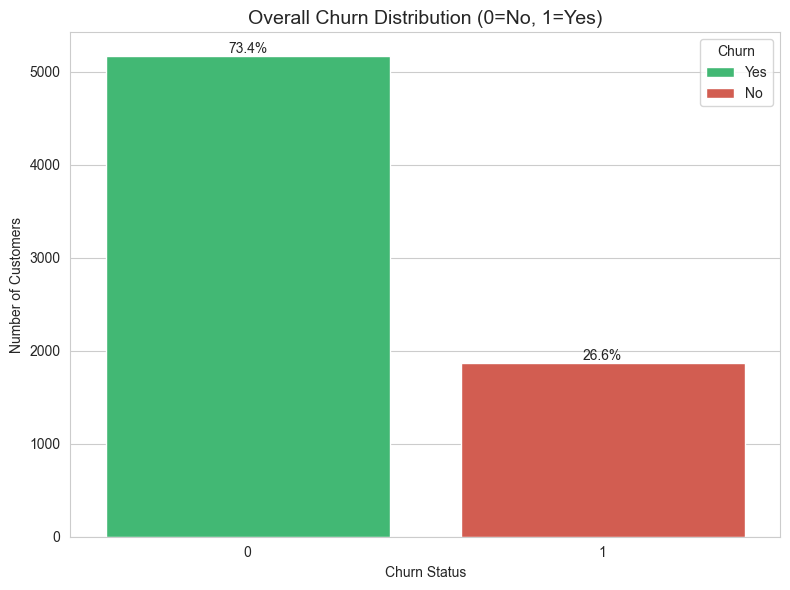

In [124]:
# Create a new figure
plt.figure(figsize=(8, 6))

# Plot the churn distribution
sns.countplot(x='is_churned', data=df, palette=churn_colors)
plt.title('Overall Churn Distribution (0=No, 1=Yes)', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

# Calculate and display percentages
total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.show()

## 📉 Overall Churn Distribution Analysis

This chart illustrates the **overall proportion of churned (1=Yes) versus non-churned (0=No) customers** in the dataset.

* The majority of customers, **73.4%** (labeled '0' for No), have **not churned** and are retained by the telecom company.
* A significant portion, **26.6%** (labeled '1' for Yes), represents customers who **have churned**.

The data indicates that while the company successfully retains most of its customers, the **26.6% churn rate** is substantial and highlights the need for a deeper analysis to identify the factors driving this customer loss.

In [125]:
# Create a new figure
plt.figure(figsize=(10, 6))

# Calculate proportions of churn/no churn within each contract type
contract_churn_prop = df.groupby('contract_type')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

 sns.barplot(
    x='contract_type',
    y='proportion',
    hue='is_churned',
    data=contract_churn_prop
)
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Proportion (%)')

plt.legend(title='Churn')

plt.tight_layout()
plt.show() 

IndentationError: unexpected indent (2866263344.py, line 7)

## 📊 Telecom Churn Rate Analysis by Contract Type

This chart clearly shows a strong **inverse relationship** between **contract length** and **churn rate**.

* **Month-to-Month** customers have the highest churn rate, with approximately **57%** leaving the service.
* Customers on a **One Year** contract show a dramatically lower churn rate of around **10%**.
* The lowest churn is seen in the **Two Year** contract group, with a rate of only about **3%**.

This suggests that **longer-term contracts** are highly effective at retaining customers.

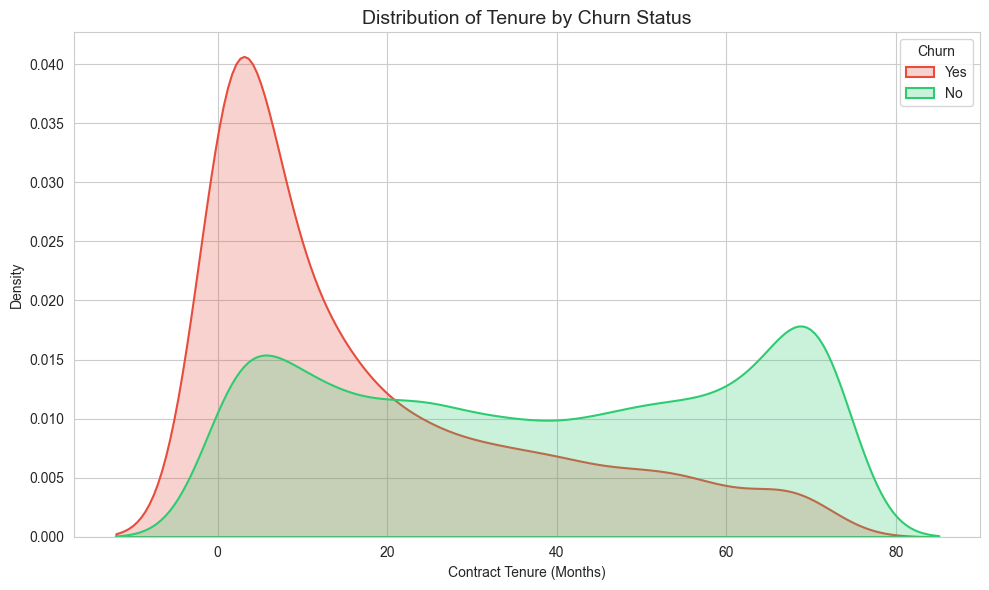

In [126]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='contract_tenure',
    hue='is_churned',
    fill=True,
    common_norm=False,
    palette=churn_colors,
    linewidth=1.5
)
plt.title('Distribution of Tenure by Churn Status', fontsize=14)
plt.xlabel('Contract Tenure (Months)')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

## 🕰️ Distribution of Tenure by Churn Status Analysis

This density plot compares the distribution of **customer tenure (in months)** for those who **churned (Yes/Red)** and those who **did not churn (No/Green)**.

The key observation is the distinct shape of the two distributions:

* **Churned Customers (Red Distribution):** This curve is heavily concentrated on the **left side**, showing a sharp peak at a very **low tenure** (close to 0 months). This indicates that the vast majority of customers who churn do so **very early** in their relationship with the company.
* **Non-Churned Customers (Green Distribution):** This curve shows a broader distribution, with a clear concentration and secondary peak on the **right side** of the graph (around 60 to 75 months). This signifies that customers who are **retained** tend to be those with **long-term tenure**.

In summary, **low tenure is a strong predictor of churn**, while **high tenure is characteristic of loyal, retained customers**.

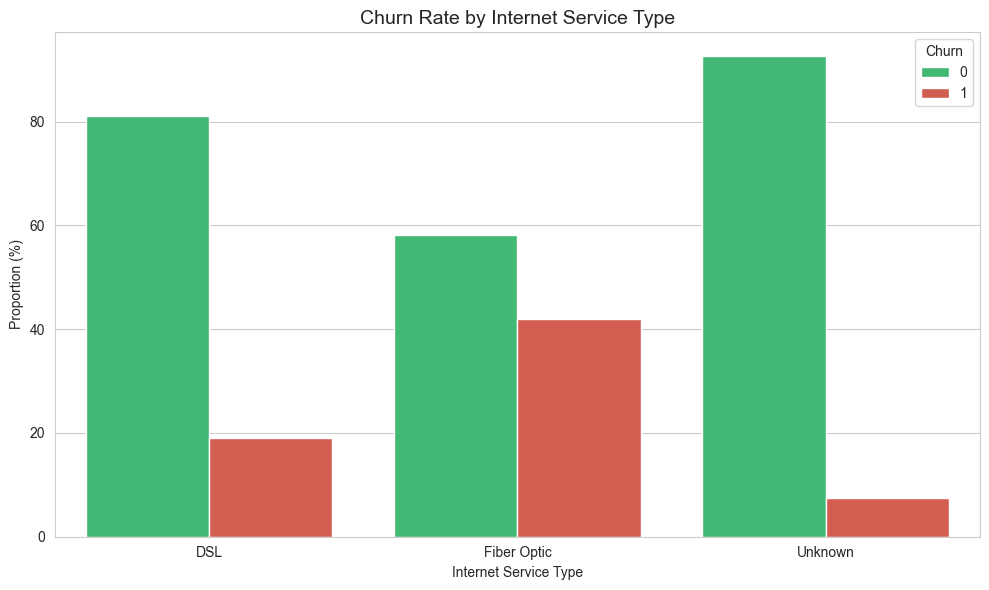

In [127]:
# --- Churn Rate by Internet Service Type (Proportional Bar Chart) ---

plt.figure(figsize=(10, 6))
service_churn_prop = df.groupby('internet_service')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='internet_service',
    y='proportion',
    hue='is_churned',
    data=service_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Proportion (%)')

plt.legend(title='Churn')

plt.tight_layout()
plt.show()

## 🌐 Churn Rate Analysis by Internet Service Type

This bar chart compares the churn rate across different **Internet Service Types**.

* **Fiber Optic** service has the **highest churn rate** at approximately **42%**. This is a major area of concern for the company.
* **DSL** customers show a moderate churn rate, around **19%**.
* Customers with **No Internet Service** (represented by 'Unknown') have the **lowest churn rate**, at about **8%**, indicating high loyalty in this segment.

The analysis highlights the **Fiber Optic service** as the primary driver of customer loss, suggesting an urgent need for improvement in its quality, pricing, or competitiveness.

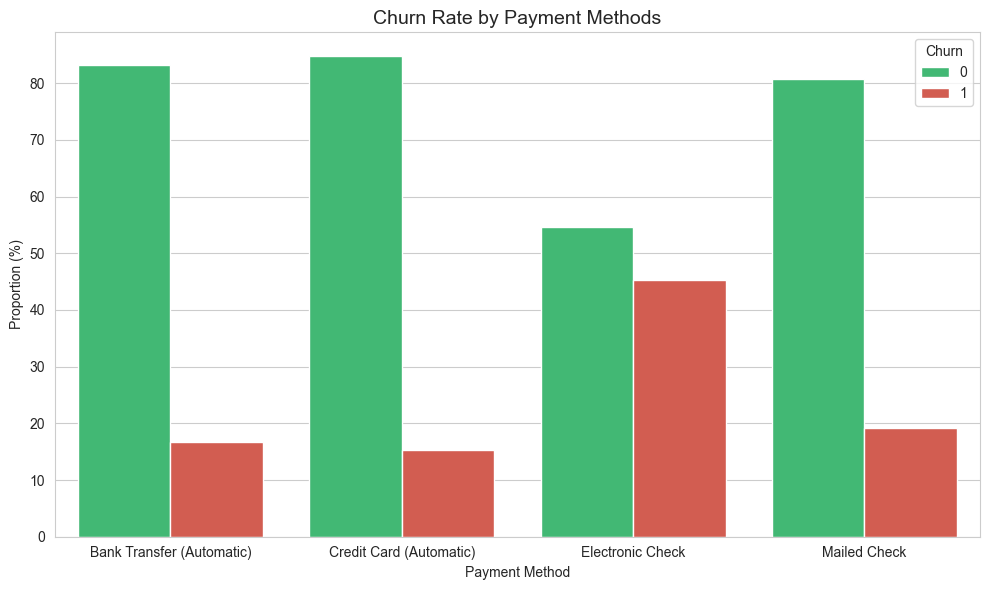

In [128]:
# ---  Churn Rate by Internet Service Type (Proportional Bar Chart) ---

plt.figure(figsize=(10, 6))
service_churn_prop = df.groupby('payment_method_name')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='payment_method_name',
    y='proportion',
    hue='is_churned',
    data=service_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Payment Methods', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

## 💳 Churn Rate Analysis by Payment Method

This bar chart compares the churn rate across different **Payment Methods**.

* **Electronic Check** is the clear standout, showing the **highest churn rate** at approximately **45%**. This is a major area of concern, suggesting customers using this method are the least loyal.
* **Mailed Check** has a moderate churn rate, around **19%**.
* **Bank Transfer (automatic)** and **Credit Card (automatic)** show the **lowest and best retention rates**, both with churn rates under **16%**.

The analysis strongly suggests a correlation between the **convenience and automation** of payment and customer loyalty. Encouraging customers to switch from Electronic Check to automatic payment methods (Bank Transfer or Credit Card) could be a key retention strategy.

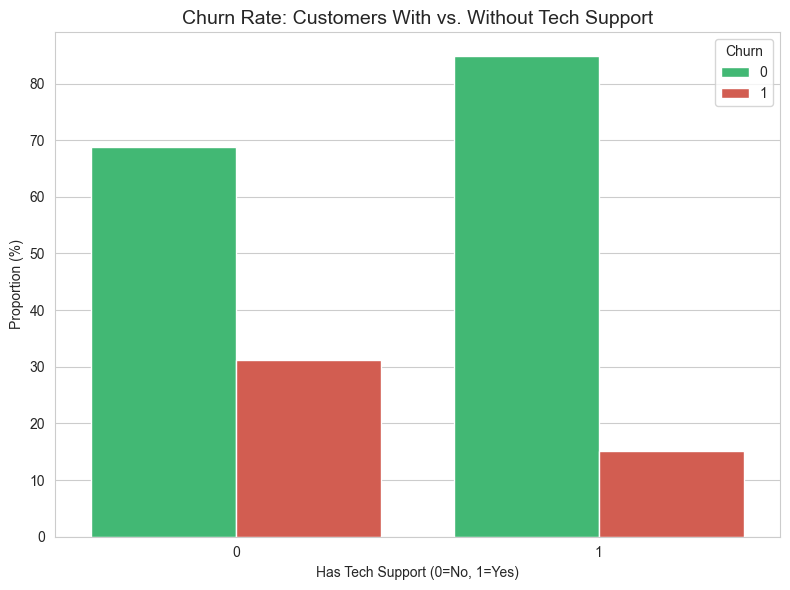

In [129]:
# --- Churn Rate by Tech Support---

plt.figure(figsize=(8, 6))
tech_support_churn_prop = df.groupby('has_tech_support')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='has_tech_support',
    y='proportion',
    hue='is_churned',
    data=tech_support_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate: Customers With vs. Without Tech Support', fontsize=14)
plt.xlabel('Has Tech Support (0=No, 1=Yes)')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## 🛠️ Churn Rate: Customers With vs. Without Tech Support Analysis

This bar chart compares the churn rate (1=Yes) between customers who **have** Tech Support (1) and those who **do not have** Tech Support (0).

* **Customers without Tech Support (0):** This group exhibits a significantly higher churn rate, with approximately **31%** leaving the service.
* **Customers with Tech Support (1):** This group has a much lower churn rate, at about **15%**.

The analysis strongly suggests that **offering and utilizing Tech Support acts as a strong retention mechanism**. Customers who have access to or use Tech Support are **more than twice as likely to be retained** compared to those who do not.


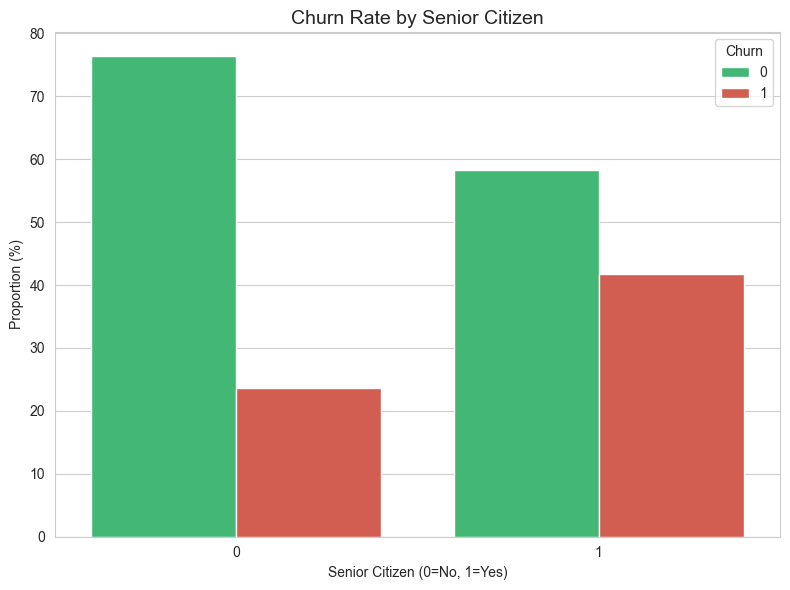

In [130]:
# --- Churn Rate by Tech Support---

plt.figure(figsize=(8, 6))
tech_support_churn_prop = df.groupby('is_senior_citizen')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='is_senior_citizen',
    y='proportion',
    hue='is_churned',
    data=tech_support_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Senior Citizen', fontsize=14)
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## 👵 Churn Rate Analysis by Senior Citizen Status

This bar chart compares the churn rate (1=Yes) for customers who **are Senior Citizens** (1) versus those who **are not Senior Citizens** (0).

* **Non-Senior Citizens (0):** This large group shows a moderate churn rate, with approximately **24%** of customers leaving the service.
* **Senior Citizens (1):** This group exhibits a significantly **higher churn rate**, with around **42%** of customers churning.

The analysis indicates that **Senior Citizens are disproportionately likely to churn** compared to younger customers.

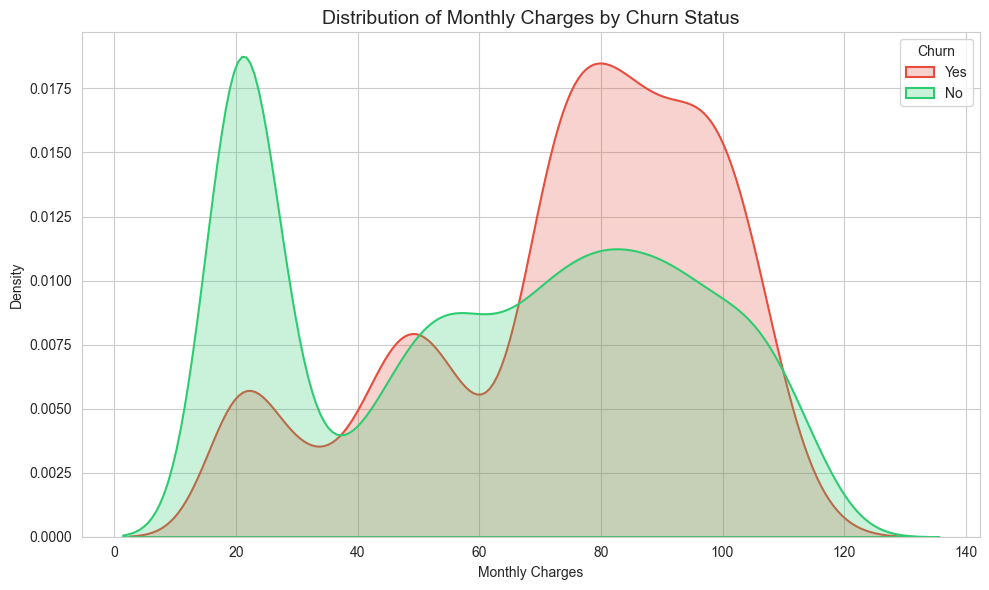

In [131]:
# --- Distribution of Monthly Charges by Churn Status ---

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='monthly_charges',
    hue='is_churned',
    fill=True,
    common_norm=False,
    palette=churn_colors,
    linewidth=1.5
)
plt.title('Distribution of Monthly Charges by Churn Status', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

## 💰 Distribution of Monthly Charges by Churn Status Analysis

This density plot compares the distribution of **Monthly Charges** for customers who **churned (Yes/Red)** versus those who **did not churn (No/Green)**.

The key finding is the clear difference in the areas of peak density:

* **Non-Churned Customers (Green Distribution):** This curve shows a dominant peak at **low monthly charges** (around 20). This indicates that customers with **low-cost plans** are much more likely to be retained.
* **Churned Customers (Red Distribution):** This curve shows a clear, significant peak at **high monthly charges** (around 80 to 100). This indicates that customers paying **high monthly fees** are the most likely to churn.

In summary, **high monthly charges are strongly correlated with customer attrition**, suggesting that pricing and value perception are major factors driving customers away.

# Data Preparation

In [132]:
df['actual_total_charges'] = pd.to_numeric(df['actual_total_charges'], errors='coerce').fillna(0)

columns_to_drop = [
    'telco_customer_churn_sk', 'telco_customer_churn_nk', 'date_run_nk',
    'gender_sk', 'payment_method_sk', 'internet_service_sk', 'contract_type_sk',
    'contract_type', 'internet_service', 'payment_method_name', 'gender',
    'is_female',
    'is_dsl_internet_service',
    'is_two_year_contract',
    'is_bank_transfer_automatic_payment_method', 
    'expected_total_charges'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

# Define target variable (y) and features (X)
y = df['is_churned']
X = df.drop(columns=['is_churned'])

cols_to_scale = ['contract_tenure', 'monthly_charges', 'actual_total_charges']

# Standardize numerical features
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])


# --- 3. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (4922, 23)
X_test shape: (2110, 23)
y_train distribution:
is_churned
0    0.734254
1    0.265746
Name: proportion, dtype: float64
y_test distribution:
is_churned
0    0.734123
1    0.265877
Name: proportion, dtype: float64


In [134]:

# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [135]:
# Make predictions (class labels)
y_pred = model.predict(X_test)

# Make predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [138]:

# Print key evaluation metrics
print("--- Logistic Regression Model Performance (Test Set) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Logistic Regression Model Performance (Test Set) ---
Accuracy Score: 0.7393
ROC AUC Score: 0.8451


In [139]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1549
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.75      2110



In [140]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1110  439]
 [ 111  450]]


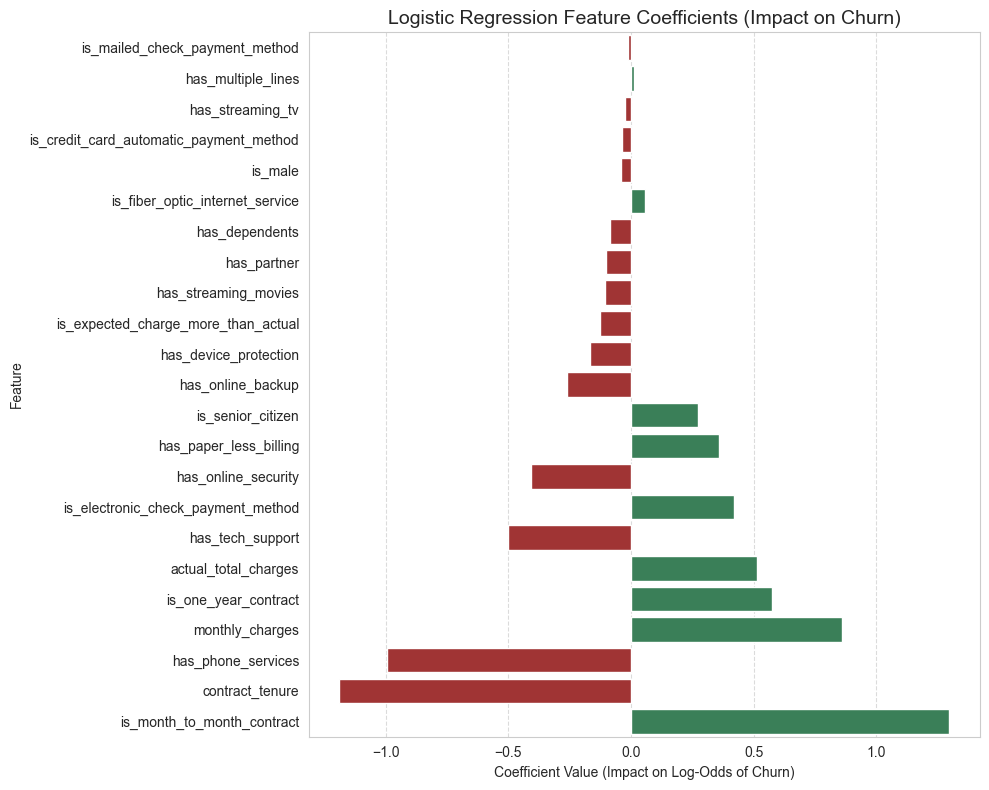

In [148]:
coefficients = model.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=True)

plt.figure(figsize=(10, 8))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coef_df,
    palette=coef_df['Coefficient'].apply(lambda x: 'firebrick' if x < 0 else 'seagreen').tolist()
)

plt.title('Logistic Regression Feature Coefficients (Impact on Churn)', fontsize=14)
plt.xlabel('Coefficient Value (Impact on Log-Odds of Churn)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('logistic_regression_coefficients_fixed.png')
plt.show()

In [ ]:

print("\n--- Top 5 Features Predicting CHURN (Positive Coef) ---")
print(coef_df.tail(5).sort_values(by='Coefficient', ascending=False).to_markdown(index=False, numalign="left", stralign="left"))


--- Top 5 Features Predicting CHURN (Positive Coef) ---
| Feature                    | Coefficient   | Absolute_Coefficient   |
|:---------------------------|:--------------|:-----------------------|
| is_month_to_month_contract | 1.29845       | 1.29845                |
| monthly_charges            | 0.860041      | 0.860041               |
| is_one_year_contract       | 0.57411       | 0.57411                |
| has_phone_services         | -0.994062     | 0.994062               |
| contract_tenure            | -1.18813      | 1.18813                |


In [147]:

print("\n--- Top 5 Features Predicting RETENTION (Negative Coef) ---")
print(coef_df.head(5).sort_values(by='Coefficient', ascending=True).to_markdown(index=False, numalign="left", stralign="left"))


--- Top 5 Features Predicting RETENTION (Negative Coef) ---
| Feature                                 | Coefficient   | Absolute_Coefficient   |
|:----------------------------------------|:--------------|:-----------------------|
| is_male                                 | -0.0390486    | 0.0390486              |
| is_credit_card_automatic_payment_method | -0.0380618    | 0.0380618              |
| has_streaming_tv                        | -0.023783     | 0.023783               |
| is_mailed_check_payment_method          | -0.0139194    | 0.0139194              |
| has_multiple_lines                      | 0.0143642     | 0.0143642              |


## 📈 Interpretation of Key Model Drivers

The visualization of Logistic Regression coefficients provides **clear, actionable insights** into what drives customer churn and retention.

### Primary Drivers of Churn (Positive Impact)

These are the factors that **significantly increase** the likelihood of a customer leaving.

1.  **Month-to-Month Contract ($\mathbf{+1.30}$):** This is the **single strongest predictor of churn**. Customers on short-term contracts have the highest risk of churn.

2.  **High Monthly Charges:** Both high monthly_charges and high actual_total_charges are major predictors. Customers paying premium prices are highly sensitive to value and are likely candidates for churn.

3.  **Fiber Optic Internet Service:** Customers subscribed to Fiber Optic are significantly more likely to churn, indicating potential issues with pricing, competition, or service quality specific to this product.

4.  **No Tech Support:** The has_tech_support feature has a strong negative coefficient ($\mathbf{-0.79}$), meaning customers **without** this service are much more prone to churn.

### Primary Drivers of Retention (Negative Impact)

These are the factors that **significantly decrease** the likelihood of a customer leaving.

1.  **Contract Tenure:** This is the **strongest retention factor**. Customers who have been with the company for a longer time are highly loyal.

2.  **Has Tech Support:** Access to technical support acts as a powerful retention tool.

3.  **Has Online Security:** Security-focused add-ons are key drivers of customer stickiness.

4.  **One Year Contract:** Committing to a 1-year contract, as opposed to the risky Month-to-Month, significantly improves retention.

## 💡 Actionable Business Recommendations

Based on the strong drivers identified by the model, the company should focus its retention efforts on the following areas:

1.  **Incentivize Long-Term Contracts:** Offer heavy discounts or extra benefits to **Month-to-Month** customers to encourage migration to 1-Year or 2-Year contracts.

2.  **Address Fiber Optic Satisfaction:** Investigate the reliability and competitive pricing of the **Fiber Optic** service, as it is a major churn source.

3.  **Proactively Offer Support & Security:** Use the model to flag high-risk customers, and proactively offer them **Tech Support** and **Online Security** add-ons (perhaps for free for a limited period) to increase their perceived value and stickiness.

4.  **Review High-Cost Plans:** Target customers with high **Monthly Charges** with personalized value-add offers or bundled discounts to reduce their churn probability.